# Temporal-SatCLIP Fine-tuning Notebook

Experimental notebook for fine-tuning Temporal-SatCLIP on downstream tasks.

Currently only support NOAA GHCNd.

In [1]:
import pandas as pd
from main import SatCLIPLightningModule
import location_encoder as LE
from temporal_encoding import Fourier, Direct
from tqdm import tqdm
from matplotlib import pyplot as plt
import torch
import torch.nn as nn


/home/leca5365/miniconda3/envs/satclip313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
# Load a pre-trained spatio-temporal SatCLIP encoder
ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-temporal-55k-temporalsplits-fixednormalizeddayofyear/satclip-fixed-normalized-day-of-year/checkpoints/last.ckpt'

lightning_model = SatCLIPLightningModule.load_from_checkpoint(ckpt_path)

lightning_model.eval()
spatiotemporal_enc = lightning_model.model.location
visual_enc = lightning_model.model.visual

using pretrained moco vit16


In [3]:
# Load the training GHCN dataset
ghcn_df_training = pd.read_csv('../notebooks/ghcn_2021_2023_temperature.csv')
print(len(ghcn_df_training))

# Load the testing GHCN dataset
ghcn_df_testing = pd.read_csv('../notebooks/ghcn_2024_2026_temperature.csv')
print(len(ghcn_df_testing))

26419496
17051878


In [14]:
# create MLP head for temperature prediction

class TemperaturePredictor(nn.Module):
    def __init__(self, location_encoder, embed_dim=256, hidden_dim=512):
        super(TemperaturePredictor, self).__init__()
        self.location_encoder = location_encoder
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Predict temperature

    def forward(self, coord):
        loc_emb = self.location_encoder(coord)
        x = torch.relu(self.fc1(loc_emb))
        temp_pred = self.fc2(x)
        return temp_pred
    
tp = TemperaturePredictor(spatiotemporal_enc)

tp.location_encoder.requires_grad_(False)

# Print trainable parameters
print("Trainable parameters:")
for name, param in tp.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

tp.to(device)
tp.double()

Trainable parameters:
fc1.weight torch.Size([512, 256])
fc1.bias torch.Size([512])
fc2.weight torch.Size([1, 512])
fc2.bias torch.Size([1])


TemperaturePredictor(
  (location_encoder): SpatioTemporalEncoder(
    (temporal_enc): Fourier()
    (pos_enc): SphericalHarmonics()
    (nnet): SirenNet(
      (layers): ModuleList(
        (0-1): 2 x Siren(
          (activation): Sine()
        )
      )
      (last_layer): Siren(
        (activation): Identity()
      )
    )
  )
  (fc1): Linear(in_features=256, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

In [5]:
import numpy as np
num_locations = 1000
random_location_ids = np.random.choice(ghcn_df_training['ID'].unique(), num_locations, replace=False) 
# print("Randomly selected location IDs for training:", random_location_ids)

In [6]:
# Subsample the dataset to a single location by ID for testing
# location_id = "USW00094728"  # Example location ID (New York Central Park)
# ghcn_df_subset = ghcn_df[ghcn_df["ID"] == location_id]
# len(ghcn_df_subset)

# Subsample the dataset to a random selection of location IDs for training
ghcn_df_subset = ghcn_df_training[ghcn_df_training['ID'].isin(random_location_ids)]

# ghcn_df_subset = ghcn_df_training.copy()  # Use the full dataset for training

In [7]:
test_all_df = ghcn_df_testing[(ghcn_df_testing["Element"]=="TMAX") & (ghcn_df_testing["QFlag"].isna())]
test_all_df['Date'] = pd.to_datetime(test_all_df['Date'], format="%Y%m%d")
test_all_df['DayOfYear'] = (test_all_df['Date'].dt.dayofyear - 1) / 364.0

/tmp/ipykernel_2667958/3466551987.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_all_df['Date'] = pd.to_datetime(test_all_df['Date'], format="%Y%m%d")
/tmp/ipykernel_2667958/3466551987.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_all_df['DayOfYear'] = (test_all_df['Date'].dt.dayofyear - 1) / 364.0


In [8]:
ghcn_test_subset_df = ghcn_df_testing[ghcn_df_testing['ID'].isin(random_location_ids)]
test_df = ghcn_test_subset_df[(ghcn_test_subset_df["Element"]=="TMAX") & (ghcn_test_subset_df["QFlag"].isna())]
test_df['Date'] = pd.to_datetime(test_df['Date'], format="%Y%m%d")
test_df['DayOfYear'] = (test_df['Date'].dt.dayofyear - 1) / 364.0

/tmp/ipykernel_2667958/2714673626.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Date'] = pd.to_datetime(test_df['Date'], format="%Y%m%d")
/tmp/ipykernel_2667958/2714673626.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['DayOfYear'] = (test_df['Date'].dt.dayofyear - 1) / 364.0


In [9]:
# Create dataloader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from torch.utils.data import DataLoader, TensorDataset, random_split

# GHCN to day-of-year and TMAX
# dataset_df = ghcn_df[(ghcn_df["Element"]=="TMAX") & (ghcn_df["QFlag"].isna())]
dataset_df = ghcn_df_subset[(ghcn_df_subset["Element"]=="TMAX") & (ghcn_df_subset["QFlag"].isna())]
dataset_df['Date'] = pd.to_datetime(dataset_df['Date'], format="%Y%m%d")
dataset_df['DayOfYear'] = (dataset_df['Date'].dt.dayofyear - 1) / 364.0

# Prepare dataset
coords = torch.tensor(dataset_df[['Longitude', 'Latitude', 'DayOfYear']].values, dtype=torch.float32).double().to(device)
temperatures = torch.tensor(dataset_df['Value'].values, dtype=torch.float32).unsqueeze(1).double().to(device)

generator = torch.Generator().manual_seed(42)

dataset = TensorDataset(coords, temperatures)

train, val = random_split(TensorDataset(coords, temperatures), [int(0.8*len(coords)), len(coords) - int(0.8*len(coords))], generator=generator)

dataloader = DataLoader(train, batch_size=8192, shuffle=True)
dataloader_val = DataLoader(val, batch_size=8192, shuffle=False)

/tmp/ipykernel_2667958/984973118.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['Date'] = pd.to_datetime(dataset_df['Date'], format="%Y%m%d")
/tmp/ipykernel_2667958/984973118.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['DayOfYear'] = (dataset_df['Date'].dt.dayofyear - 1) / 364.0


In [ ]:
# Temporal-only encoder + prediction head
# temporal_proj = LE.get_temporal_encoding("fourier", k=10)
# enc_head = LE.get_neural_network("siren", temporal_proj.embedding_dim, num_classes=256, dim_hidden=256, num_layers=2)
# temporal_encoder = LE.LocationEncoder(temporal_proj, enc_head)

# tp = TemperaturePredictor(temporal_encoder)

In [ ]:
# Fine-tune the predictor head
from tqdm import tqdm

opt = torch.optim.AdamW(tp.parameters(), lr=1e-3, weight_decay=False)
criterion = nn.MSELoss()

num_epochs = 50
epoch_losses = []
epoch_val_losses = []

for epoch in tqdm(range(num_epochs)):
    tp.train()
    total_loss = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        coords_batch, temp_batch = batch
        # coords_batch, temp_batch = coords_batch.to(device), temp_batch.to(device)
        opt.zero_grad()
        temp_pred = tp(coords_batch)  # Only use temporal part of the coordinates
        loss = criterion(temp_pred, temp_batch)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    # print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    epoch_losses.append(avg_loss)

    # Get validation error
    total_loss = 0
    for batch in dataloader_val:
        coords_batch, temp_batch = batch

        with torch.no_grad():
            temp_pred = tp(coords_batch)  # Only use temporal part of the coordinates
            loss = criterion(temp_pred, temp_batch)
            total_loss += loss.item()
    avg_val_loss = total_loss / len(dataloader_val)
    # print(f"Epoch {epoch+1}/{num_epochs}, Val Loss: {avg_val_loss:.4f}")
    epoch_val_losses.append(avg_val_loss)

100%|██████████| 50/50 [19:55<00:00, 23.91s/it]


In [16]:
torch.save(tp.state_dict(), "temperature_predictor.pth")

In [17]:
# Load the model if needed
tp.load_state_dict(torch.load("temperature_predictor.pth"))
tp.to(device)

TemperaturePredictor(
  (location_encoder): SpatioTemporalEncoder(
    (temporal_enc): Fourier()
    (pos_enc): SphericalHarmonics()
    (nnet): SirenNet(
      (layers): ModuleList(
        (0-1): 2 x Siren(
          (activation): Sine()
        )
      )
      (last_layer): Siren(
        (activation): Identity()
      )
    )
  )
  (fc1): Linear(in_features=256, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

In [11]:
# Plot training and validation loss
plt.plot(epoch_losses, label='Training Loss')
plt.plot(epoch_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

NameError: name 'epoch_losses' is not defined

In [52]:
# Create a temporal encoder for the day of year
temporal_encoder = Fourier(k=10).to(device)

class TemperaturePredictorWithTemporal(nn.Module):
    def __init__(self, temporal_encoder, hidden_dim=512):
        super(TemperaturePredictorWithTemporal, self).__init__()
        self.temporal_encoder = temporal_encoder
        self.fc1 = nn.Linear(temporal_encoder.embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Predict temperature

    def forward(self, coord):
        temporal_emb = self.temporal_encoder(coord[:, 2].unsqueeze(1))  # Use day of year for temporal encoding
        x = torch.relu(self.fc1(temporal_emb))
        temp_pred = self.fc2(x)
        return temp_pred
    
tp_temporal = TemperaturePredictorWithTemporal(temporal_encoder)

In [53]:
class TemperaturePredictorHead(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=512):
        super(TemperaturePredictorHead, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Predict temperature

    def forward(self, input):
        x = torch.relu(self.fc1(input))
        temp_pred = self.fc2(x)
        return temp_pred

In [54]:
# Fine-tune the predictor head
from tqdm import tqdm

# tph = TemperaturePredictorHead(input_dim=3, hidden_dim=128)
tph = TemperaturePredictorWithTemporal(temporal_encoder)

for param in tph.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(tph.parameters(), lr=1e-3, weight_decay=False)
criterion = nn.MSELoss()

tph.to(device)
tph.double()

num_epochs = 100
for epoch in tqdm(range(num_epochs)):
    tph.train()
    total_loss = 0

    for batch in tqdm(dataloader):
        coords_batch, temp_batch = batch
        # coords_batch, temp_batch = coords_batch.to(device), temp_batch.to(device)
        opt.zero_grad()
        temp_pred = tph(coords_batch)
        loss = criterion(temp_pred, temp_batch)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

100%|██████████| 1/1 [00:00<00:00, 196.36it/s]


Epoch 1/100, Loss: 40368.0969


100%|██████████| 1/1 [00:00<00:00, 231.51it/s]


Epoch 2/100, Loss: 40332.5421


100%|██████████| 1/1 [00:00<00:00, 176.60it/s]


...

Epoch 98/100, Loss: 32700.8843


100%|██████████| 1/1 [00:00<00:00, 269.85it/s]


Epoch 99/100, Loss: 32547.0350


100%|██████████| 100/100 [00:00<00:00, 203.47it/s]

Epoch 100/100, Loss: 32391.6195


In [40]:
dataset_df[['ID', 'Name', 'Latitude', 'Longitude']][1000:1100]

,ID,Name,Latitude,Longitude
24178173,USW00094728,NY CITY CNTRL PARK,40.7789,-73.9692
24201454,USW00094728,NY CITY CNTRL PARK,40.7789,-73.9692
24225157,USW00094728,NY CITY CNTRL PARK,40.7789,-73.9692
24248972,USW00094728,NY CITY CNTRL PARK,40.7789,-73.9692
24272786,USW00094728,NY CITY CNTRL PARK,40.7789,-73.9692
...,...,...,...,...
26318983,USW00094728,NY CITY CNTRL PARK,40.7789,-73.9692
26342773,USW00094728,NY CITY CNTRL PARK,40.7789,-73.9692
26366570,USW00094728,NY CITY CNTRL PARK,40.7789,-73.9692
26389971,USW00094728,NY CITY CNTRL PARK,40.7789,-73.9692


In [56]:
tph.temporal_encoder(torch.tensor([[1.0], [182.0], [365.0]], dtype=torch.float32).to(device)).shape

torch.Size([3, 20])

600084
tensor([[-1.2353e+02,  4.8567e+01,  0.0000e+00],
        [-1.2462e+02,  4.9400e+01,  0.0000e+00],
        [-1.2843e+02,  5.0783e+01,  0.0000e+00],
        ...,
        [-9.8880e+01,  3.6576e+01,  1.2637e-01],
        [-7.8714e+01,  4.1898e+01,  1.2637e-01],
        [-7.9917e+01,  3.9783e+01,  1.2637e-01]], device='cuda:0',
       dtype=torch.float64)
tensor(-494.2260, device='cuda:0', dtype=torch.float64)
Predicted Mean: 17.689796162283972
True Mean: 17.298329233907253


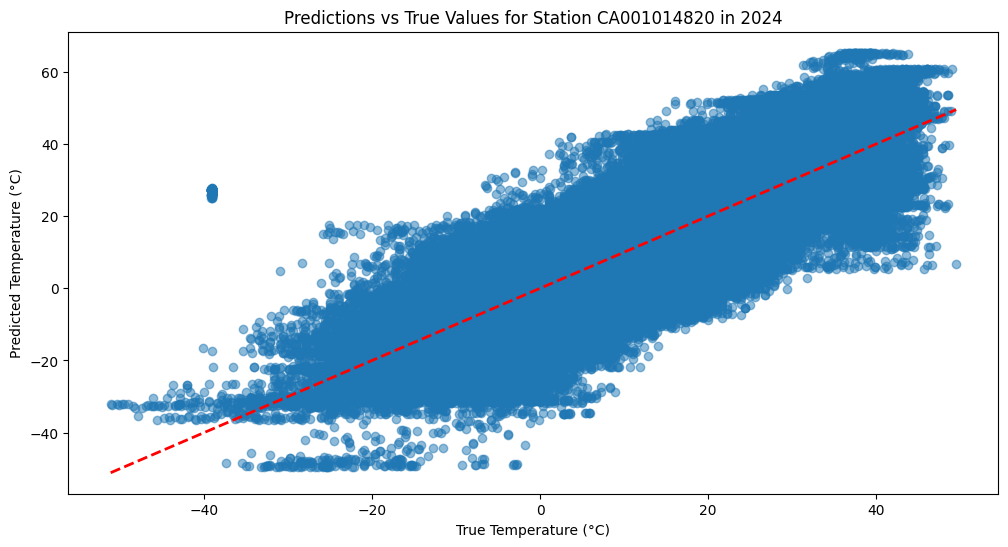

/tmp/ipykernel_2667958/1904472746.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


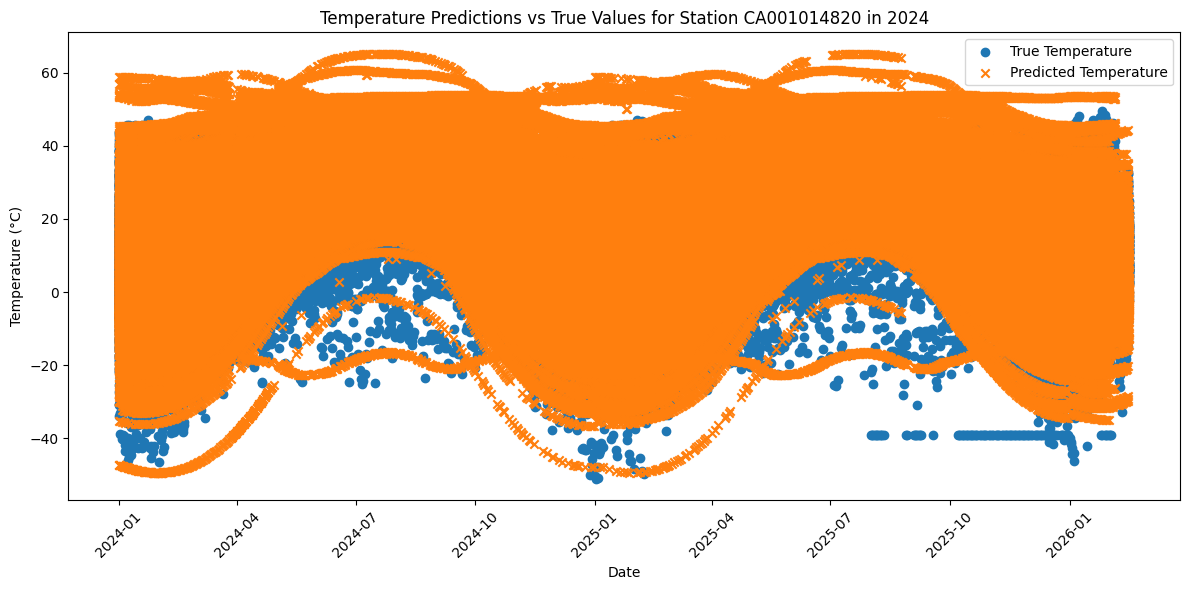

In [18]:
# Plot the predictions vs true values for a given location in 2023
import matplotlib.pyplot as plt

# Select a specific location (e.g., station ID 0000012345)
# selected_station = dataset_df[dataset_df['ID'] == 'RSM00032121']
# selected_station = dataset_df[dataset_df['ID'] == location_id]
# selected_station = test_df[test_df['ID'].isin([random_location_ids[7]])]
# selected_station = test_df
# selected_station = test_all_df
more_random_location_ids = np.random.choice(test_all_df['ID'].unique(), 1000, replace=False)
selected_station = test_all_df[test_all_df['ID'].isin(more_random_location_ids)]
print(len(selected_station))

# Get predictions for this station
coords_selected = torch.tensor(selected_station[['Longitude', 'Latitude', 'DayOfYear']].values, dtype=torch.float32).double().to(device)
print(coords_selected)
with torch.no_grad():
    # pred_selected = tph(coords_selected)
    pred_selected = tp(coords_selected)  # Only use temporal part of the coordinates
    print(pred_selected.min())

# Convert to numpy for plotting
print("Predicted Mean:", pred_selected.mean().item() / 10.0)
print("True Mean:", selected_station['Value'].mean() / 10.0)
pred_selected_np = pred_selected.cpu().numpy().flatten() / 10.0  # Convert from tenths of degrees C to degrees C
true_values_np = selected_station['Value'].values / 10.0  # Convert from tenths of degrees C to degrees C

# Plot predictions vs true values
plt.figure(figsize=(12, 6))
plt.scatter(true_values_np, pred_selected_np, alpha=0.5)
plt.plot([true_values_np.min(), true_values_np.max()], [true_values_np.min(), true_values_np.max()], 'r--', lw=2)
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title(f'Predictions vs True Values for Station {selected_station["ID"].iloc[0]} in {selected_station["Date"].dt.year.iloc[0]}')
plt.show()

# Plot predictions and true values over time for the selected station
plt.figure(figsize=(12, 6))
plt.scatter(selected_station['Date'], true_values_np, label='True Temperature', marker='o')
plt.scatter(selected_station['Date'], pred_selected_np, label='Predicted Temperature', marker='x')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Predictions vs True Values for Station {selected_station["ID"].iloc[0]} in {selected_station["Date"].dt.year.iloc[0]}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
print(coords_selected.shape)
print(pred_selected.shape)
print(true_values_np.shape)

torch.Size([31074, 3])
torch.Size([31074, 1])
(31074,)


In [19]:
# Create GIF of predictions over time for all stations on Basemap (cyl) and another GIF of true values over time for all stations on Basemap (cyl), collect by month

from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable

from PIL import Image
import io
frames = []

temp_min = min(pred_selected_np.min(), true_values_np.min())
temp_max = max(pred_selected_np.max(), true_values_np.max())

for doy in tqdm(np.linspace(0, 1, 12)):  # Loop over months
    fig, ax = plt.subplots(2,1, figsize=(20, 10))

    # Plot predictions
    m = Basemap(projection='cyl', resolution='c', ax=ax[0])
    m.drawcoastlines()

    # Land mask
    t_coords_idx = np.abs(coords_selected[:, 2].cpu().numpy() - doy) < 30/364  # Within 30 days of doy
    t_coords = coords_selected[t_coords_idx][:, :2].cpu().numpy()
    t_preds = pred_selected[t_coords_idx].cpu().numpy() / 10.0  # Convert from tenths of degrees C to degrees C

    sc0 = ax[0].scatter(t_coords[:, 0], t_coords[:, 1], s=10, c=t_preds, cmap='coolwarm', label="Location", vmin=temp_min, vmax=temp_max)
    ax[0].set_title(f"Predicted Temps | Day of Year: {doy*364:.0f}")

    # Plot true values
    m = Basemap(projection='cyl', resolution='c', ax=ax[1])
    m.drawcoastlines()

    # Land mask
    t_coords_idx = np.abs(coords_selected[:, 2].cpu().numpy() - doy) < 30/364  # Within 30 days of doy
    t_coords = coords_selected[t_coords_idx][:, :2].cpu().numpy()
    t_preds = true_values_np[t_coords_idx]  # Use true values instead of predictions

    sc1 = ax[1].scatter(t_coords[:, 0], t_coords[:, 1], s=10, c=t_preds, cmap='coolwarm', label="Location", vmin=temp_min, vmax=temp_max)

    ax[1].set_title(f"True Temps | Day of Year: {doy*364:.0f}")

    fig.colorbar(sc1, label='Temperature (°C)')

    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))

    plt.close(fig)

frames[0].save('NOAA-GHCNd-finetuned-predictions.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)

100%|██████████| 12/12 [00:18<00:00,  1.56s/it]
